# Slimmc + pyslimmc — simple Colab workflow

Minimal styrene free-radical polymerization example.

The notebook:
1. installs the Slimmc Linux binary and pyslimmc,
2. writes a `.model` file,
3. checks and runs the model,
4. opens the result with pyslimmc and plots the MWD.

In [14]:
# Install Slimmc 5.0.3 and pyslimmc 5.0.1 from GitHub Releases

!wget -q https://github.com/sbednarz/slimmc/releases/download/slimmc-v5.0.3/slimmc-5.0.3-linux-x86_64-glibc_2.28.zip
!unzip -q slimmc-5.0.3-linux-x86_64-glibc_2.28.zip
!cp slimmc-5.0.3-linux-x86_64-glibc_2.28/bin/slimmc /usr/local/bin/
!cp slimmc-5.0.3-linux-x86_64-glibc_2.28/bin/slimmc-summary /usr/local/bin/
!chmod +x /usr/local/bin/slimmc /usr/local/bin/slimmc-summary

!wget -q https://github.com/sbednarz/slimmc/releases/download/pyslimmc-v5.0.1/pyslimmc-5.0.1-py3-none-any.whl
!pip install -q pyslimmc-5.0.1-py3-none-any.whl

!slimmc --version

replace slimmc-5.0.3-linux-x86_64-glibc_2.28/bin/slimmc? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace slimmc-5.0.3-linux-x86_64-glibc_2.28/bin/slimmc-summary? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace slimmc-5.0.3-linux-x86_64-glibc_2.28/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace slimmc-5.0.3-linux-x86_64-glibc_2.28/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace slimmc-5.0.3-linux-x86_64-glibc_2.28/VERSION? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Slimmc 5.0.3

Build
  mode:          release
  optimization:  speed
  Nim:           2.2.10
  backend:       C
  target:        linux/amd64
  compiled:      2026-08-15 15:04:33
  build timestamp: 2026-08-15T15:04:32Z
  git commit:    40d7b28327a550d0f384c0ecf8a67a609dee8e23
  git tag:       slimmc-v5.0.3
  git dirty:     false


## Simple FRP model

Styrene + AIBN at 60 °C.

Illustrative textbook-style constants:
- `kd = 8.5e-6 s^-1`
- `kp = 377 L mol^-1 s^-1`
- `kt = 6.0e7 L mol^-1 s^-1`

`ki = kp` is used here as a simple initiation assumption.

In [26]:
%%writefile styrene.model
# Simple styrene FRP with AIBN at 60 C

desc "Simple styrene FRP"

param output_dir "results/styrene"
param kmc_volume 3.0e-16
param temperature 333.15
param t_end 72000
param seed 12345

monomer Sty 1.0 104.15
species AIBN 1.0e-2
species R 0.0

polymer P active
polymer D dead

rate kd  const 8.5e-6
rate ki  const 377.0
rate kp  const 377.0
rate ktc const 6.0e7

rxn AIBN -> R + R kd 0.6

macro init   R + Sty -> P ki
macro prop   P + Sty -> P kp
macro term_c P + P -> D ktc

every 360 save
every 360 print_info
at 72000 save_chains

Overwriting styrene.model


In [27]:
# Check and run
!rm -rf results/styrene
!slimmc styrene.model
!slimmc-summary results/styrene

[start] run_id=styrene t_end=7.20e+04 output=results/styrene
[run] event=0 t=0.00e+00/7.20e+04 0.0% conv=Sty:0.0000 wall=0.1s 2026-08-16T18:19:17Z
[run] event=741255 t=3.60e+02/7.20e+04 0.5% conv=Sty:0.0041 wall=0.3s 2026-08-16T18:19:18Z
[run] event=1463316 t=7.20e+02/7.20e+04 1.0% conv=Sty:0.0080 wall=0.5s 2026-08-16T18:19:18Z
[run] event=2182001 t=1.08e+03/7.20e+04 1.5% conv=Sty:0.0119 wall=0.7s 2026-08-16T18:19:18Z
[run] event=2890729 t=1.44e+03/7.20e+04 2.0% conv=Sty:0.0158 wall=0.9s 2026-08-16T18:19:18Z
[run] event=3598814 t=1.80e+03/7.20e+04 2.5% conv=Sty:0.0197 wall=1.2s 2026-08-16T18:19:19Z
[run] event=4296040 t=2.16e+03/7.20e+04 3.0% conv=Sty:0.0235 wall=1.4s 2026-08-16T18:19:19Z
[run] event=4995395 t=2.52e+03/7.20e+04 3.5% conv=Sty:0.0273 wall=1.6s 2026-08-16T18:19:19Z
[run] event=5700123 t=2.88e+03/7.20e+04 4.0% conv=Sty:0.0312 wall=1.8s 2026-08-16T18:19:19Z
[run] event=6386675 t=3.24e+03/7.20e+04 4.5% conv=Sty:0.0349 wall=2.0s 2026-08-16T18:19:19Z
[run] event=7077792 t=3.60

status: completed
total polymerization time: 1200.0 min
styrene conversion: 49.8%
Mn: 18894
Mw: 30403
D: 1.609


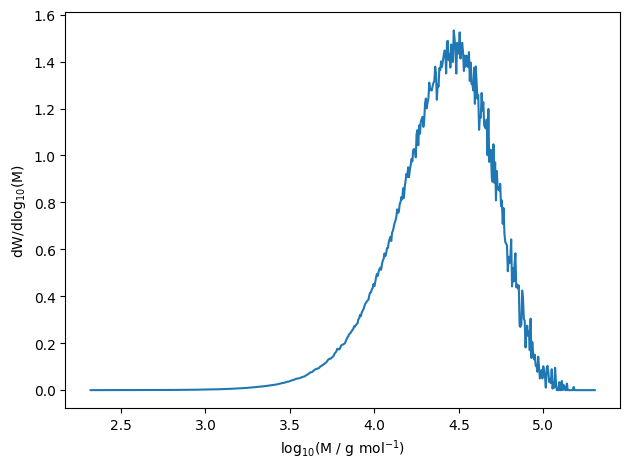

In [28]:
# Analyse with pyslimmc

import matplotlib.pyplot as plt
import pyslimmc as sl

run = sl.open("results/styrene")

print("status:", run.status)
print(f"total polymerization time: {run.t[-1] / 60:.1f} min")
print(f"styrene conversion: {100*run.conv['Sty'][-1]:.1f}%")
print(f"Mn: {run.final.mn:.0f}")
print(f"Mw: {run.final.mw:.0f}")
print(f"D: {run.final.dispersity:.3f}")

mwd = run.final.mwd()

plt.plot(mwd.x, mwd.y)
plt.xlabel(r"log$_{10}$(M / g mol$^{-1}$)")
plt.ylabel(r"dW/dlog$_{10}$(M)")
plt.tight_layout()
plt.show()